In [1]:
from spockflow.components.tree import Tree, Action
from spockflow.core import initialize_spock_module
import pandas as pd

/Users/cp371651/.pyenv/versions/3.12.2/envs/spock/lib/python3.12/site-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [2]:
from typing_extensions import TypedDict

class Reject(TypedDict):
    code: int
    description: str

RejectAction = Action[Reject]

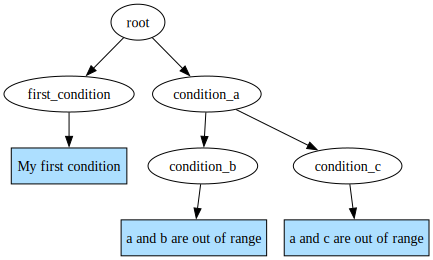

In [3]:
tree = Tree()
@tree.condition(output=RejectAction(code=102, description="My first condition"))
def first_condition(d: pd.Series, e: pd.Series, f: pd.Series) -> pd.Series:
    return (d > 5) & (e > 5) & (f > 5)

@tree.condition()
def condition_a(a: pd.Series) -> pd.Series:
    return a > 5

@condition_a.condition(output=RejectAction(code=100, description="a and b are out of range"))
def condition_b(b: pd.Series) -> pd.Series:
    return b > 5

@condition_a.condition(output=RejectAction(code=101, description="a and c are out of range"))
def condition_c(c: pd.Series) -> pd.Series:
    return c > 5
tree.visualize(get_value_name=lambda x: x["description"][0])

In [4]:
tree.model_dump_json()

PydanticSerializationError: Error serializing to JSON: PydanticSerializationError: Unable to serialize unknown type: <class 'pandas.core.frame.DataFrame'>